In [1]:
import sys
sys.path.append('.')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params_all_cores
from params_all_cores import set_params
import time
import importlib

In [ ]:
# to be used when connecting to Dynap-se via remote server (Zemo)
#model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [2]:
# to be used when connecting to Dynap-se locally 
devices = samna.device.get_unopened_devices()
model   = samna.device.open_device(devices[int(0)])

In [7]:
api = model.get_dynapse1_api()
config1 = model.get_configuration()
param_group_c0 = config1.chips[0].cores[0].parameter_group 
param_group_c1 = config1.chips[0].cores[1].parameter_group 
param_group_c2 = config1.chips[0].cores[2].parameter_group 
param_group_c3 = config1.chips[0].cores[3].parameter_group 

In [8]:
param_list = ["IF_AHTAU_N", "IF_AHTHR_N", "IF_AHW_P", "IF_BUF_P", "IF_DC_P", "IF_NMDA_N", "IF_RFR_N", "IF_TAU1_N", "IF_TAU2_N", "IF_THR_N", "NPDPIE_TAU_F_P", "NPDPIE_TAU_S_P", "NPDPIE_THR_F_P", "NPDPIE_THR_S_P", 
              "NPDPII_TAU_F_P", "NPDPII_TAU_S_P", "NPDPII_THR_F_P", "NPDPII_THR_S_P", "PS_WEIGHT_EXC_F_N", "PS_WEIGHT_EXC_S_N", "PS_WEIGHT_INH_F_N", "PS_WEIGHT_INH_S_N", "PULSE_PWLK_P", "R2R_P"]

In [9]:
"""for i in param_list:
    print(param_group_c2.param_map[i])"""

'for i in param_list:\n    print(param_group_c2.param_map[i])'

LIF encoding

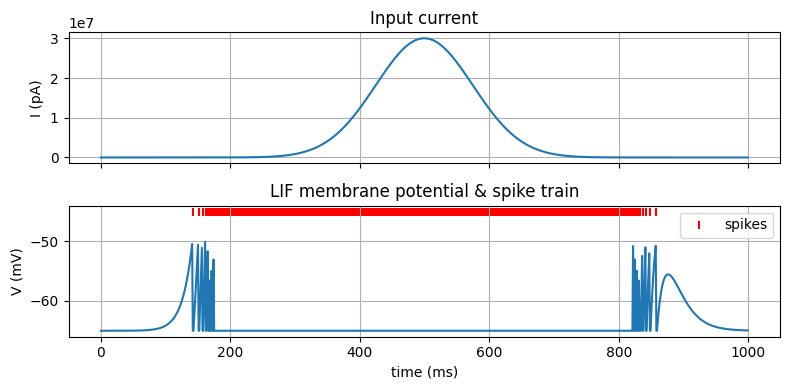

In [10]:
# ----------------  stimulus: a Gaussian bump ----------------
n_pts     = 1000                 # number of samples
t_end     = 1.0                  # seconds  (→ dt = 1 ms)
t         = np.linspace(0, t_end, n_pts, endpoint=False)
x         = np.linspace(-4, 4, n_pts)
sigma = 0.6  # Try smaller values: 1.0 (default), 0.5, 0.25, etc.
gauss = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * (x / sigma)**2)
I_peak    = 30000000e-12              # 1000 pA

I         = gauss/gauss.max() * I_peak   # injected current (A)

# ----------------  LIF neuron parameters ----------------------
tau_m     = 20e-3                # 20 ms membrane time constant
R_m       = 100e6                # 100 MΩ  (=> C = tau/R)
C_m       = tau_m / R_m
v_rest    = -65e-3               # -65 mV
v_reset   = -65e-3
v_thresh  = -50e-3               # spike threshold
t_ref     = 2e-3                 # 2 ms refractory period
dt        = t_end / n_pts        # simulation time-step (s)

# ----------------  simulation loop ----------------------------
v        = v_rest
next_ok  = 0.0                   # time when refractory ends
v_trace  = np.empty(n_pts)
spikes   = []

for k in range(n_pts):
    if t[k] >= next_ok:          # not in refractory
        dv = (-(v - v_rest) + R_m * I[k]) / (R_m * C_m) * dt
        v += dv
        if v >= v_thresh:        # spike!
            spikes.append(t[k])
            v = v_reset
            next_ok = t[k] + t_ref
    v_trace[k] = v

spikes = np.array(spikes)

# ----------------  plots --------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,4), sharex=True)

ax1.plot(t*1e3, I*1e12)
ax1.set_ylabel('I (pA)'); ax1.set_title('Input current'); ax1.grid()

ax2.plot(t*1e3, v_trace*1e3)
ax2.scatter(spikes*1e3, np.full(len(spikes), (v_thresh+5e-3)*1e3),
            marker='|', color='red', label='spikes')
ax2.set_xlabel('time (ms)')
ax2.set_ylabel('V (mV)')
ax2.set_title('LIF membrane potential & spike train')
ax2.legend(); ax2.grid()
plt.tight_layout(); plt.show()

In [11]:
spike_times_all = spikes#*1e3

In [12]:
spike_times_all

array([0.142, 0.151, 0.157, 0.162, 0.166, 0.169, 0.172, 0.175, 0.178,
       0.18 , 0.182, 0.184, 0.186, 0.188, 0.19 , 0.192, 0.194, 0.196,
       0.198, 0.2  , 0.202, 0.204, 0.206, 0.208, 0.211, 0.213, 0.215,
       0.217, 0.219, 0.221, 0.223, 0.225, 0.227, 0.229, 0.231, 0.233,
       0.235, 0.237, 0.239, 0.242, 0.244, 0.246, 0.248, 0.25 , 0.252,
       0.254, 0.256, 0.258, 0.26 , 0.262, 0.264, 0.266, 0.268, 0.27 ,
       0.272, 0.274, 0.276, 0.278, 0.28 , 0.282, 0.284, 0.286, 0.288,
       0.291, 0.293, 0.295, 0.297, 0.299, 0.301, 0.303, 0.305, 0.307,
       0.309, 0.311, 0.313, 0.315, 0.317, 0.319, 0.321, 0.323, 0.325,
       0.327, 0.329, 0.331, 0.333, 0.335, 0.337, 0.339, 0.341, 0.343,
       0.345, 0.347, 0.349, 0.351, 0.354, 0.356, 0.358, 0.36 , 0.362,
       0.364, 0.366, 0.368, 0.37 , 0.372, 0.374, 0.376, 0.378, 0.38 ,
       0.382, 0.384, 0.386, 0.388, 0.39 , 0.392, 0.394, 0.396, 0.398,
       0.4  , 0.402, 0.404, 0.406, 0.408, 0.41 , 0.412, 0.414, 0.416,
       0.419, 0.421,

In [13]:
spike_ids = np.full(len(spikes), 1)

In [14]:
spikegen_ids = [(0, 1, n) for n in range(10)]

In [15]:
print(spikegen_ids)

[(0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 1, 5), (0, 1, 6), (0, 1, 7), (0, 1, 8), (0, 1, 9)]


In [16]:
# double checking connections
"""
# create neuron populations in the ring
chip = 0
core = 1
npop = 1
NBINS = 10

# Create neuron populations for each band in core 0
ring_pops = [
    [Neuron(chip, core, j) for j in range((i * npop), ((i + 1) * npop))]
    for i in range(NBINS)
]

OFFSET_1 = (-1, 1)          # ±3 bins wide “hat”

print("excitatory connections to first neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_1:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                print(pre, post)
                print(pre, post)
                print(pre, post)

OFFSET_2 = (-2, 2)          # ±3 bins wide “hat”

    # todo excitatory connections to second neighbors
print(" ")
print("excitatory connections to second neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_2:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                print(pre, post)
                print(pre, post)

OFFSET_3 = (-3, 3)          # ±3 bins wide “hat”
    # todo excitatory connections to third neighbors
print(" ")
print("excitatory connections to third neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_3:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                print(pre, post)

    # todo inhibitory connections to all of the other pops
OFFSET_inh = (-5, -4, 4, 5)          # all of the pops that are not being excited
print(" ")
print("inhibitory connections to all of the other pops")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_inh:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                print(pre, post)
"""

'\n# create neuron populations in the ring\nchip = 0\ncore = 1\nnpop = 1\nNBINS = 10\n\n# Create neuron populations for each band in core 0\nring_pops = [\n    [Neuron(chip, core, j) for j in range((i * npop), ((i + 1) * npop))]\n    for i in range(NBINS)\n]\n\nOFFSET_1 = (-1, 1)          # ±3 bins wide “hat”\n\nprint("excitatory connections to first neighbors")\nfor i, pop_i in enumerate(ring_pops):\n    for pre in pop_i:\n        for d in OFFSET_1:\n            j = (i + d) % NBINS          # wrap around\n            for post in ring_pops[j]:\n                print(pre, post)\n                print(pre, post)\n                print(pre, post)\n\nOFFSET_2 = (-2, 2)          # ±3 bins wide “hat”\n\n    # todo excitatory connections to second neighbors\nprint(" ")\nprint("excitatory connections to second neighbors")\nfor i, pop_i in enumerate(ring_pops):\n    for pre in pop_i:\n        for d in OFFSET_2:\n            j = (i + d) % NBINS          # wrap around\n            for post in rin

In [17]:
import params_all_cores

importlib.reload(params_all_cores)
config1 = model.get_configuration()


 
PS_WEIGHT_EXC_F_N, AMPA weight
Coarse: 6
Fine: 20
 
NPDPIE_THR_F_P, AMPA threshold
Coarse: 4
Fine: 80
 
PS_WEIGHT_INH_S_N, GABA B weight
Coarse: 7
Fine: 20
 
NPDPII_THR_S_P, GABA B threshold
Coarse: 4
Fine: 80
 
PS_WEIGHT_EXC_S_N, PS_WEIGHT_EXC_S_N weight
Coarse: 6
Fine: 30
ring populations:  [[C0c3n10, C0c3n11, C0c3n12], [C0c3n13, C0c3n14, C0c3n15], [C0c3n16, C0c3n17, C0c3n18], [C0c3n19, C0c3n20, C0c3n21], [C0c3n22, C0c3n23, C0c3n24], [C0c3n25, C0c3n26, C0c3n27], [C0c3n28, C0c3n29, C0c3n30], [C0c3n31, C0c3n32, C0c3n33], [C0c3n34, C0c3n35, C0c3n36], [C0c3n37, C0c3n38, C0c3n39]]
C0c0s1
excitatory connections to first neighbors
 
excitatory connections to second neighbors
 
excitatory connections to third neighbors
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

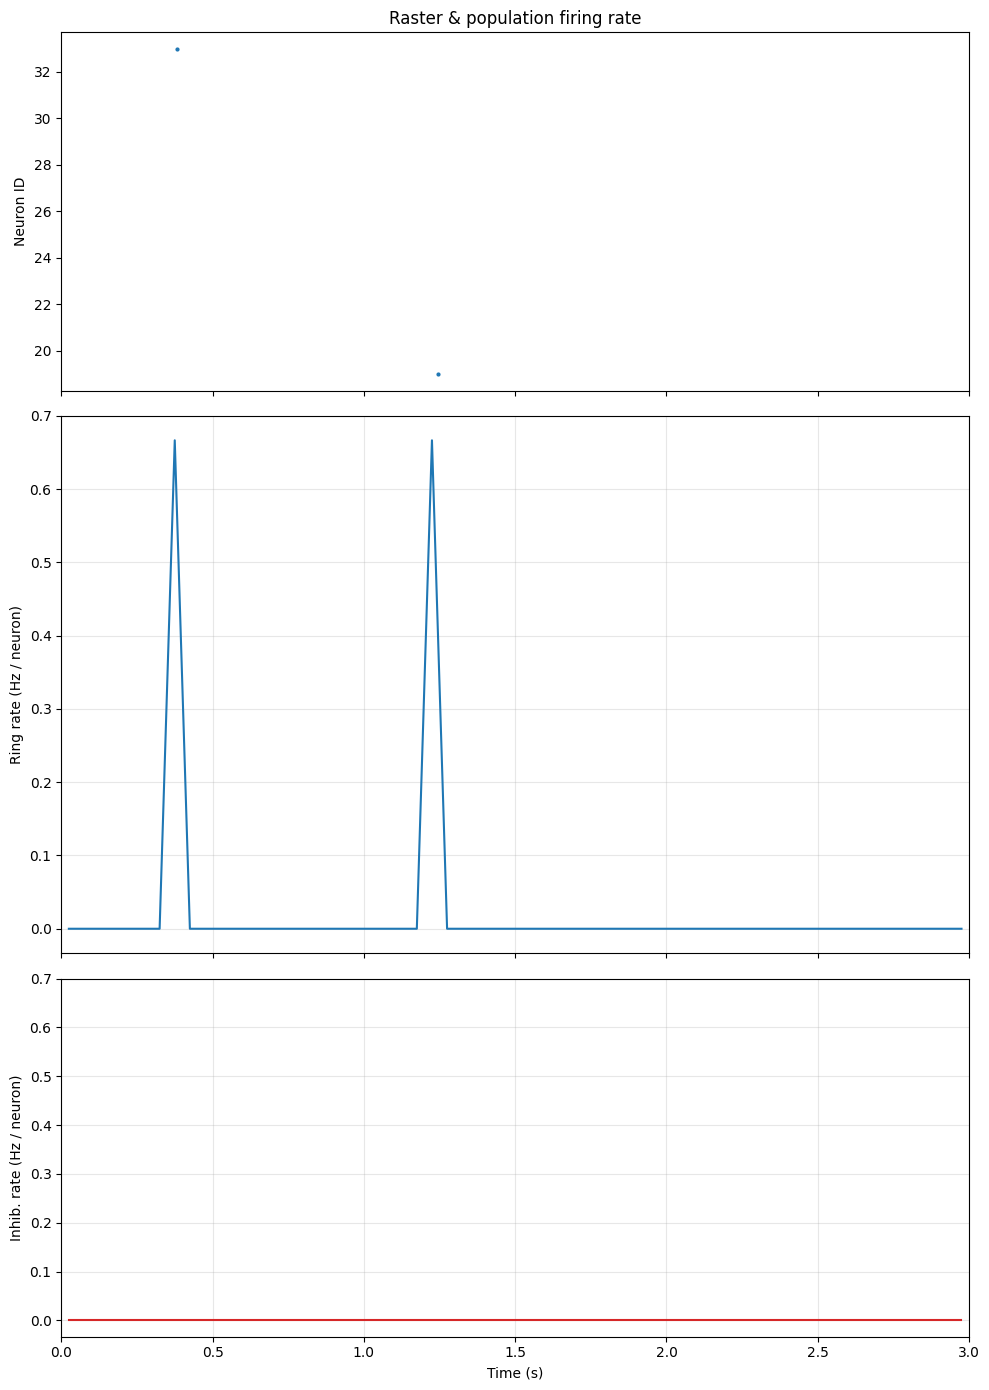

In [ ]:
#importlib.reload(params_all_cores)
#model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

importlib.reload(params_all_cores)

config1 = model.get_configuration()
param_group_c0 = config1.chips[0].cores[0].parameter_group 

print(" ")

print("PS_WEIGHT_EXC_F_N, AMPA weight")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

print(" ")

print("NPDPIE_THR_F_P, AMPA threshold")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_THR_F_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_THR_F_P'].fine_value))

print(" ")

print("PS_WEIGHT_INH_S_N, GABA B weight")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

print(" ")

print("NPDPII_THR_S_P, GABA B threshold")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPII_THR_S_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPII_THR_S_P'].fine_value))

print(" ")

print("PS_WEIGHT_EXC_S_N, PS_WEIGHT_EXC_S_N weight")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))

p_E_E   = 0.5
p_mexican = 1
p_I_I   = 0 #1
p_E_I   = 0 #0.1
p_I_E   = 1 #0.4

# initiate network 
net_gen = NetworkGenerator()
net_gen.clear_network()

# create spikegens, one per ring attractor neural pop 
spikegen_ids = [(0, 0, n) for n in range(10)]

spikegens = []
for spikegen_id in spikegen_ids:
    spikegens.append(Neuron(spikegen_id[0], spikegen_id[1],spikegen_id[2], True))

# create neuron populations in the ring
chip = 0
core = 3
npop = 3
NBINS = 10

# Create neuron populations for each band in core 0
ring_pops = [
    [Neuron(chip, core, j) for j in range(10 + (i * npop), 10 + ((i + 1) * npop))]
    for i in range(NBINS)
]

print("ring populations: ", ring_pops)    

# create inhibitory population that connects to all other pops
core_inh = 1
start_inh_neuron = 4
npop_inh = 4
pop_inhibitory = [Neuron(chip, core_inh, j) for j in range(start_inh_neuron, start_inh_neuron + npop_inh, 1)]
pop_inhibitory
    
"""# spikegen connected to neuron 1 # single connection one spikegen to one neuron
net_gen.add_connection(spikegens[0], neurons_E[1], dyn1.Dynapse1SynType.AMPA)
for n in neurons_E:
    print(n)
    net_gen.add_connection(spikegens[0], n, dyn1.Dynapse1SynType.AMPA)"""

# connect each spikegen to a ring attractor pop 
"""for bin_idx, sg in enumerate(spikegens):       
    for exc in ring_pops[bin_idx]:
        net_gen.add_connection(sg, exc, dyn1.Dynapse1SynType.AMPA)"""

print(spikegens[1])
        
for i in ring_pops[3]:
    net_gen.add_connection(spikegens[1], i, dyn1.Dynapse1SynType.AMPA)
    

# self excitation in each neural population in the ring: (todo determine if this is needed) 
for pop in ring_pops:
    for pre in pop:
        for post in pop:
            if pre is not post and np.random.rand() < p_E_E:
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                
# MEXICAN HAT CONNECTIONS
OFFSET_1 = (-1, 1)         
print("excitatory connections to first neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_1:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                #net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.AMPA)

OFFSET_2 = (-2, 2)          # ±3 bins wide “hat”

    # todo excitatory connections to second neighbors
print(" ")
print("excitatory connections to second neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_2:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)
                #net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.AMPA)

OFFSET_3 = (-3, 3)          # ±3 bins wide “hat”
    # todo excitatory connections to third neighbors
print(" ")
print("excitatory connections to third neighbors")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_3:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                print(" ")
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.NMDA)

    # todo inhibitory connections to all of the other pops
OFFSET_inh = (-6, -5, -4, 4, 5, 6)          # all of the pops that are not being excited
print(" ")
print("inhibitory connections to all of the other pops")
for i, pop_i in enumerate(ring_pops):
    for pre in pop_i:
        for d in OFFSET_inh:
            j = (i + d) % NBINS          # wrap around
            for post in ring_pops[j]:
                net_gen.add_connection(pre, post, dyn1.Dynapse1SynType.GABA_B)

# INH → EXC  (global inhibition pop to all pops in the ring)
for inh in pop_inhibitory:
    for pop in ring_pops:
        for exc in pop:
            net_gen.add_connection(inh, exc, dyn1.Dynapse1SynType.GABA_B)

# EXC → INH  (drive the global inhibition pop from all pops in the ring)
for pop in ring_pops:
    for exc in pop:
        for inh in pop_inhibitory:
            net_gen.add_connection(exc, inh, dyn1.Dynapse1SynType.NMDA)

# Print the network for verification (optional)
print(net_gen.network)

# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

# apply the configuration
model.apply_configuration(new_config)

# Set hardware parameters
set_params(model)

print("PS_WEIGHT_INH_S_N, GABA B weight")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

# IF_DC_P

print("IF_DC_P, DC")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_DC_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_DC_P'].fine_value))

#for rate in [50]:
D_stim = 3 # stimulus duration (s)
D_post_stim = 3 # post stimulus duration (s)
D = D_stim + D_post_stim

fpga_spike_gen = model.get_fpga_spike_gen() # set FPGA 

# get events of selected neurons
monitored_neurons = [
    (n.chip_id, n.core_id, n.neuron_id)   
    for pop in ring_pops
    for n   in pop
]

monitored_neurons.extend([
    (neuron.chip_id, neuron.core_id, neuron.neuron_id)
    for neuron in pop_inhibitory  
])

"""random_pop = [Neuron(chip, core_inh, j) for j in range(70, 200, 1)]

monitored_neurons.extend([
    (neuron.chip_id, neuron.core_id, neuron.neuron_id)
    for neuron in random_pop  
])"""

graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()

# clear the buffer
sink_node.get_events()

# select the neurons to monitor
print("monitored neurons:", monitored_neurons)
filter_node.set_neurons(monitored_neurons)

api.reset_timestamp()

time.sleep(0)

spike_times_s = spike_times_all  # spike_times_all is in seconds!!!

#spike_ids     = np.asarray(spike_ids,   dtype=np.int32).tolist()
#spike_times_s = np.asarray(spike_times_s, dtype=np.float64).tolist()

ut.set_fpga_spike_gen(
    fpga_spike_gen,
    spike_times_all,
    spike_ids,
    target_chips=[0] * len(spike_ids),
    isi_base=900,
    repeat_mode=False)

fpga_spike_gen.start()

#time.sleep(D_post_stim)
timesleep = 3
time.sleep(timesleep)

fpga_spike_gen.stop()

graph.stop()
events = sink_node.get_events()

# process the events
print(len(events), "events.")

NN = 256 # neurons in 1 core
spike_id = []
spike_t  = []
for evt in events:
    #spike_id.append(evt.core_id*NN + evt.neuron_id)
    spike_id.append(evt.neuron_id)
    spike_t.append(evt.timestamp*1e-6)
spike_id = np.array(spike_id)
spike_t  = np.array(spike_t) 

"""
plt.scatter(spike_t, spike_id)#, marker='|')

plt.tight_layout()
#plt.ylim(0, 30)
plt.xlim(0, timesleep)
#plt.savefig('EI.png')
plt.xlabel("Time (s)")
plt.ylabel("Neuron ID")

plt.show()"""

# ========== plotting =========
import numpy as np
import matplotlib.pyplot as plt

# 1. Split spikes into ring vs inhibitory
ring_ids = {n.neuron_id for pop in ring_pops for n in pop}
inh_ids  = {n.neuron_id for n in pop_inhibitory}

ring_mask = np.isin(spike_id, list(ring_ids))
inh_mask  = np.isin(spike_id, list(inh_ids))

# 2. Binning
bin_size  = 0.050            # 50 ms
t_edges   = np.arange(0, timesleep + bin_size, bin_size)
t_centers = t_edges[:-1] + bin_size/2

# 3. Histogram → Hz per neuron
def rate(mask, n_units):
    counts, _ = np.histogram(spike_t[mask], bins=t_edges)
    return counts / max(n_units,1) / bin_size    # avoid divide-by-0

ring_rate_hz = rate(ring_mask, len(ring_ids))
inh_rate_hz  = rate(inh_mask,  len(inh_ids))

# 4. Plot
fig, (ax_raster, ax_ring, ax_inh) = plt.subplots(
        3, 1, sharex=True, figsize=(10,14),
        gridspec_kw={'height_ratios':[1,1.5,1]})

# ── link only the two firing-rate axes ────────────────────────────
ax_inh.sharey(ax_ring)                
#ax_inh.tick_params(labelleft=False)    # hide the duplicate tick labels

# Raster
ax_raster.scatter(spike_t, spike_id, s=4)
ax_raster.set_ylabel("Neuron ID")
ax_raster.set_xlim(0, timesleep)
ax_raster.set_title("Raster and population firing rate")

# Ring population rate
ax_ring.plot(t_centers, ring_rate_hz, lw=1.5)
ax_ring.set_ylabel('Ring rate (Hz / neuron)')
ax_ring.grid(alpha=.3)

# Inhibitory population rate
ax_inh.plot(t_centers, inh_rate_hz, lw=1.5, color='tab:red')
ax_inh.set_ylabel('Inhib. rate (Hz / neuron)')
ax_inh.set_xlabel('Time (s)')
ax_inh.grid(alpha=.3)

plt.tight_layout()
plt.show()

In [19]:
#ut.close_dynapse1(model)